In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from skimage import data
from skimage.metrics import peak_signal_noise_ratio as psnr, mean_squared_error as mse, structural_similarity as ssim

from skimage.filters import gaussian, median

from skimage.morphology import footprint_rectangle

from IPython.display import display

import math

# Učitavanje slike i vrednosti potrebnih parametara

In [3]:
def load_image(image_path):
    if os.path.exists(image_path):
        image = Image.open(image_path).convert('L')
        return np.asarray(image, dtype=np.float64)
    return np.asarray(data.camera(), dtype=np.float64)

In [4]:
IMAGE_PATHS = ['flowers.jpg', 'landscapes.jpg', 'profile.jpg']
NOISE_STD_DEV = 20            # standardna devijacija šuma za lambda eksperiment
STD_VAR = [10, 20, 30, 40, 50]  # niz intenziteta šuma za poredjenje

# Dodavanje šuma

Vezu između originalne slike(u) i slike sa šumom(f) predstavljamo modelom:

    f = u + η
pri čemu je η šum koji se dodaje. Šum je slučajna vrednost iz Gausove(normalne) raspodele, odnosno iz raspodele sa srednjom vrednošću 0, a intenzitet šuma zavisi od izabrane standardne devijacije.


In [5]:

def add_gaussian_noise(image, std_dev):
    noisy_image = image + np.random.normal(0.0, std_dev, image.shape)
    return np.clip(noisy_image, 0.0, 255.0)


# Gausov i Median filteri - konvolucija


U kontekstu slika, konvolucija predstavlja kompoziciju dveju matrica. Veća matrica je matrica piksela originalne slike, a manja matrica filter koji se primenjuje. Filter se pomera preko slika i za svaki piksel računa novu vrednost na osnovu:

1. operacije koja je definisana
2. okoline centralnog piksela - okolina je definisana veličinom filtera

#### Gausov filter:

1. posmatra grupu piksela u okviru prozora definisanog veličinom matrice filtera MxM
2. svakom pikselu u okviru prozora dodeljuje se težina i računa se ponderisana srednja vrednost
3. vrednost centralnog piksela postavlja na izračunatu srednju vrednost

##### Parametri:
1. slika iz koje se elimiše šum
2. sigma - širina Gausove raspodele, određuje koliki uticaj imaju bliži, odnosno udaljeniji pikseli
3. preserve_range - vrednosti ostaju u istom opsegu kao i originalna slika

#### Median filter:
    
1. posmatra grupu piksela u okviru prozora definisanog veličinom matrice filtera MxM
2. sortira posmatrane vrednosti
3. vrednost centralnog piksela postavlja na medijanu sortiranog niza

##### Parametri:
1. slika iz koje se elimiše šum
2. footprint - veličina matrice filtera


In [6]:

def denoise_gaussian_filter(image, std_dev):
    return gaussian(image, sigma=std_dev, preserve_range=True)

def denoise_median_filter(image, size):
    return median(image, footprint=footprint_rectangle((size, size)))
    

# Chambolle algoritam

In [7]:



def forward_gradient(u):
    gx = np.zeros_like(u)
    gy = np.zeros_like(u)
    gx[:, :-1] = u[:, 1:] - u[:, :-1]
    gy[:-1, :] = u[1:, :] - u[:-1, :]
    return gx, gy

def divergence(px, py):
    div = np.zeros_like(px)
    div[:, 0] = px[:, 0]
    div[:, 1:] = px[:, 1:] - px[:, :-1]
    div[0, :] += py[0, :]
    div[1:, :] += py[1:, :] - py[:-1, :]
    return div

def chambolle_projection(f, lam, dt=0.248, tol=1e-2, max_iter=5000, p=None):
    px = np.zeros_like(f) if p is None else p[0].copy()
    py = np.zeros_like(f) if p is None else p[1].copy()

    for _ in range(max_iter):
        gx, gy = forward_gradient(divergence(px, py) - f / lam)
        norm = np.sqrt(gx * gx + gy * gy)
        denom = 1.0 + dt * norm
        px_new = (px + dt * gx) / denom
        py_new = (py + dt * gy) / denom
        change = max(np.max(np.abs(px_new - px)), np.max(np.abs(py_new - py)))
        px, py = px_new, py_new
        if change <= tol:
            break

    u = np.clip(f - lam * divergence(px, py), 0.0, 255.0)
    return u, (px, py)

def denoise_tv(noisy_image, std_dev=20, n_outer=5, lam=None):
    sigma = std_dev
    n = np.sqrt(noisy_image.size)
    if lam is None:
        lam = 1.0 / (2.1237 / std_dev + 2.0547 / (std_dev ** 2))
    p = None
    u = noisy_image
    for _ in range(n_outer):
        u, p = chambolle_projection(noisy_image, lam, p=p)
        residual = np.linalg.norm(u - noisy_image)
        lam = lam * (n * sigma) / residual
    return u

# Pomoćne funkcije za grafički prikaz rezultata

In [8]:
def compare(*images):

    img_num = len(images) // 2

    plt.figure(figsize=(12, 3*img_num))

    for i in range(img_num):
        plt.subplot(1, img_num, i + 1)
        plt.imshow(images[2*i], cmap='gray', vmin=0, vmax=255)
        plt.title(images[2*i + 1])
        plt.axis('off')

    plt.tight_layout()
    plt.show()


def plot_orginal_and_noisy(original_image, noisy_image):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(original_image, cmap='gray', vmin=0, vmax=255)
    plt.title('Original')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(noisy_image, cmap='gray', vmin=0, vmax=255)
    plt.title('Sa sumom')
    plt.axis('off')


# Vizuelizacija signala

Svaki red matrice slike je zapravo 1D signal. Da bismo jednostavno ilustrovali uticaj šuma i analizirali efekat filtera za njegovu eliminaciju, biramo jedan reprezentativni red matrice slike za grafički prikaz.
Dodavanje šuma na sliku dovodi do oštećenja slike koja se ogledaju u naglim promenama intenziteta signala, odnosno signal nam je vizuelno  "reckav". Primenom filtera za eliminaciju šuma zapravo eliminišemo odgovarajuće frekvencije.

In [9]:
def plot_signal(*images):

    img_num = len(images) // 2
    row = images[0].shape[0] // 2 # biramo reprezentativni red matrice, u ovom slučaju sredinu slike

    plt.figure(figsize=(12, 3*img_num))

    for i in range(img_num):
        #row = images[2*i].shape[0] // 2
        
        plt.subplot(img_num, 2, 2*i + 1)
        plt.imshow(images[2*i], cmap='gray', vmin=0, vmax=255)
        plt.title(images[2*i + 1])
        plt.axis('off')

        plt.subplot(img_num, 2, 2*i + 2)
        plt.plot(images[2*i][row, :], color='blue', linewidth=1.5)
        plt.title(images[2*i + 1])
        plt.grid(True, alpha=0.3)
        plt.ylim([0, 255])

    plt.tight_layout()
    plt.show()


# Uklanjanje šuma različitim algoritmima

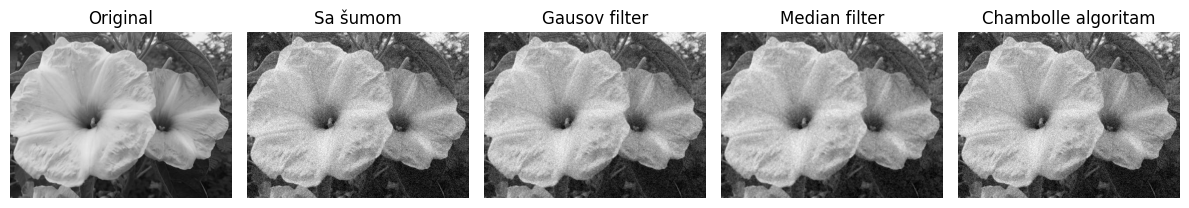

In [10]:
original_image = load_image('flowers.jpg')

noisy_image = add_gaussian_noise(original_image, NOISE_STD_DEV)

gaussian_denoised = denoise_gaussian_filter(noisy_image, 0.5)

median_denoised = denoise_median_filter(noisy_image, 3)

tv_denoised = denoise_tv(noisy_image, 0.1)

compare(original_image, "Original", noisy_image, "Sa šumom", gaussian_denoised, "Gausov filter", median_denoised, "Median filter", \
        tv_denoised, "Chambolle algoritam")

#compare(tv_denoised)

# Kako se Chambolle TV ponaša za različite λ vrednosti

Parametar λ je regularizacioni parametar koji kontroliše odnos izmedju uklanjanja šuma i očuvanja detalja slike. Veće vrednosti omogućavaju bolje uklanjaju šum, ali nekada previše izglađuju slike. Sa druge strane manje vrednosti će ukloniti manje šuma, ali će sačuvati detalje i oštre ivice.


In [11]:

def denoise_with_diff_lamda(image_path):
    print(f'\n{"="*80}')
    print(f'Slika: {image_path}')
    print(f'{"="*80}')

    original_image = load_image(image_path)
    noisy_image = add_gaussian_noise(original_image, NOISE_STD_DEV)

    diff_lambda_values = [10, 15, 20, 25, 30]
    tv_denoised_images = []
    for value in diff_lambda_values:
        u, _ = chambolle_projection(noisy_image, value)
        tv_denoised_images.append(u)

    # Priprema liste svih slika za prikaz (Original, Noisy, i očišćene)
    images_to_plot = [original_image, noisy_image] + tv_denoised_images
    titles = ['Original', f'Sa šumom (std={NOISE_STD_DEV})'] + [f'Chambolle λ={val}' for value, val in zip(tv_denoised_images, diff_lambda_values)]

    # Kreiramo prozor sa 2 reda (1. red cele slike, 2. red zumiran isečak)
    fig, axes = plt.subplots(
        2, len(images_to_plot),
        figsize=(22, 10)
    )

    # Računanje centra za zumirani isečak (crop 200x200 piksela)
    h, w = original_image.shape
    cy, cx = h // 2, w // 2
    size = 100

    for i, (image, title) in enumerate(zip(images_to_plot, titles)):
        # Gornji red: CELA SLIKA
        axes[0, i].imshow(image, cmap='gray', vmin=0, vmax=255)
        axes[0, i].set_title(title)
        axes[0, i].axis('off')
        
        # Donji red: ZUMIRAN ISEČAK (crop)
        crop = image[max(0, cy-size):min(h, cy+size), max(0, cx-size):min(w, cx+size)]
        axes[1, i].imshow(crop, cmap='gray', vmin=0, vmax=255)
        axes[1, i].set_title('Uvećano (200x200)')
        axes[1, i].axis('off')

    plt.suptitle(f'{image_path}', fontsize=16, fontweight='bold')
    plt.subplots_adjust(wspace=0.05, hspace=0.1)
    plt.show()

    # Signal plot
    plot_signal(original_image, "Original", noisy_image, "Sa šumom",
               tv_denoised_images[0], 'Chambolle TV filter, lambda = 10',
               tv_denoised_images[1], 'Chambolle TV filter, lambda = 15',
               tv_denoised_images[2], 'Chambolle TV filter, lambda = 20',
               tv_denoised_images[3], 'Chambolle TV filter, lambda = 25',
               tv_denoised_images[4], 'Chambolle TV filter, lambda = 30')


# Kako različiti algoritmi reaguju na povećanje intenziteta šuma?

Cilj ove sekcije je ispitivanje robusnosti algoritama u slučaju povećanja intenziteta šuma. Promenom parametra std_dev kontrolišemo intenzitet šuma, dok parametri algoritma ostaju nepromenjeni.
Kvalitet dobijenih rekonstrukcija analiziraćemo pomoću metrika PSNR (Peak Signal-to-Noise Ratio), SSIM (Structural Similarity Index) i MSE (Mean Squared Errors). Na osnovu dobijenih rezultata možemo proceniti koji algoritam pokazuje najveću stabilnost.

## Metrike za proveru kvaliteta očišćene slike u odnosu na originalnu

# MSE (Mean Squared Errors)

Matematička formula za računanje MSE je:

$$
\mathrm{MSE} = \frac{1}{MN}
\sum_{i=1}^{M}\sum_{j=1}^{N}
\left(I(i,j)-K(i,j)\right)^2
$$

pri čemu su parametri:

1. M i N = dimenzije slike (broj redova i kolona)

2. I(i,j) = vrednost piksela originalne slike

3. K(i,j) = vrednost piksela očišćene slike

Vrednost MSE-a treba da bude što manja, jer manja vrednost znači da je razlika između originalne i transformisane slike manja, odnosno da je kvalitet čišćenja bolji.

# PSNR (Peak Signal-to-Noise Ratio)

Matematička formula za računanje PSNR:
$$
    PSNR = 10 * \log_{10}((MAX)^2/MSE)
$$  
pri čemu su parametri:

1. MAX = maksimalna vrednost piksela u slici

2. MSE = srednje kvadratna razlika izmedju vrednosti piksela originalne i transformisane slike

Veća vrednost PSNR-a ukazuje na veću sličnost između originalne i očiščene slike, odnosno na bolji kvalitet rezultata.


# SSIM (Structural Similarity Index)

Matematička formula za računanje SSIM-a je:

$$
\mathrm{SSIM}(x,y)=
\frac{(2\mu_x\mu_y+C_1)(2\sigma_{xy}+C_2)}
{(\mu_x^2+\mu_y^2+C_1)(\sigma_x^2+\sigma_y^2+C_2)}
$$

pri čemu su:

1. $\mu_x$ i $\mu_y$ = srednje vrednosti piksela originalne i očiščene slike

2. $\sigma_x^2$ i $\sigma_y^2$ = varijanse piksela originalne i očiščene slike

3. $\sigma_{xy}$ = kovarijansa između originalne i očiščene slike

4. $C_1$ i $C_2$ = konstante koje stabilizuju formulu


Vrednost SSIM-a se najčešće nalazi u opsegu od 0 do 1, a vrednost bliža 1 označava veću sličnost između originalne i očiščene slike.


In [12]:

def denoise_different_intensity(image_path):
    print(f'\n{"="*60}')
    print(f'Slika: {image_path}')
    print(f'{"="*60}')
    std_var = STD_VAR
    noisy_images = []
    gaussian_denoised_images = []
    median_denoised_images = []
    tv_denoised_images = []
    original_image = load_image(image_path)
    for i, std in enumerate(std_var):
        noisy_images.append(add_gaussian_noise(original_image, std))
        gaussian_denoised_images.append(denoise_gaussian_filter(noisy_images[i], 0.5))
        median_denoised_images.append(denoise_median_filter(noisy_images[i], 3))
        tv_denoised_images.append(denoise_tv(noisy_images[i], NOISE_STD_DEV))
    # Metrike
    psnr_gaussian = [round(psnr(original_image, g, data_range=255), 2) for g in gaussian_denoised_images]
    psnr_median = [round(psnr(original_image, m, data_range=255), 2) for m in median_denoised_images]
    psnr_tv = [round(psnr(original_image, t, data_range=255), 2) for t in tv_denoised_images]
    ssim_gaussian = [round(ssim(original_image, g, data_range=255), 4) for g in gaussian_denoised_images]
    ssim_median = [round(ssim(original_image, m, data_range=255), 4) for m in median_denoised_images]
    ssim_tv = [round(ssim(original_image, t, data_range=255), 4) for t in tv_denoised_images]
    mse_gaussian = [round(mse(original_image, g), 2) for g in gaussian_denoised_images]
    mse_median = [round(mse(original_image, m), 2) for m in median_denoised_images]
    mse_tv = [round(mse(original_image, t), 2) for t in tv_denoised_images]
    data = {
        "Noise intensity (std)": std_var,
        "PSNR Gaussian": [f"{p} dB" for p in psnr_gaussian],
        "PSNR Median": [f"{p} dB" for p in psnr_median],
        "PSNR Chamb TV": [f"{p} dB" for p in psnr_tv],
        "SSIM Gaussian": ssim_gaussian,
        "SSIM Median": ssim_median,
        "SSIM Chamb TV": ssim_tv,
        "MSE Gaussian": mse_gaussian,
        "MSE Median": mse_median,
        "MSE Chamb TV": mse_tv
    }
    df = pd.DataFrame(data)
    print(f'\nRezultati za {image_path}:')
    display(df)
    # Grafici
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(std_var, psnr_gaussian, marker='o', label='Gaussian')
    plt.plot(std_var, psnr_median, marker='o', label='Median')
    plt.plot(std_var, psnr_tv, marker='o', label='Chambolle TV')
    plt.xlabel('Standardna devijacija suma')
    plt.ylabel('PSNR (dB)')
    plt.title(f'PSNR — {image_path}')
    plt.legend()
    plt.grid(True)
    plt.subplot(1, 2, 2)
    plt.plot(std_var, ssim_gaussian, marker='s', label='Gaussian')
    plt.plot(std_var, ssim_median, marker='s', label='Median')
    plt.plot(std_var, ssim_tv, marker='s', label='Chambolle TV')
    plt.xlabel('Standardna devijacija suma')
    plt.ylabel('SSIM')
    plt.ylim(0, 1)
    plt.title(f'SSIM — {image_path}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



Slika: flowers.jpg


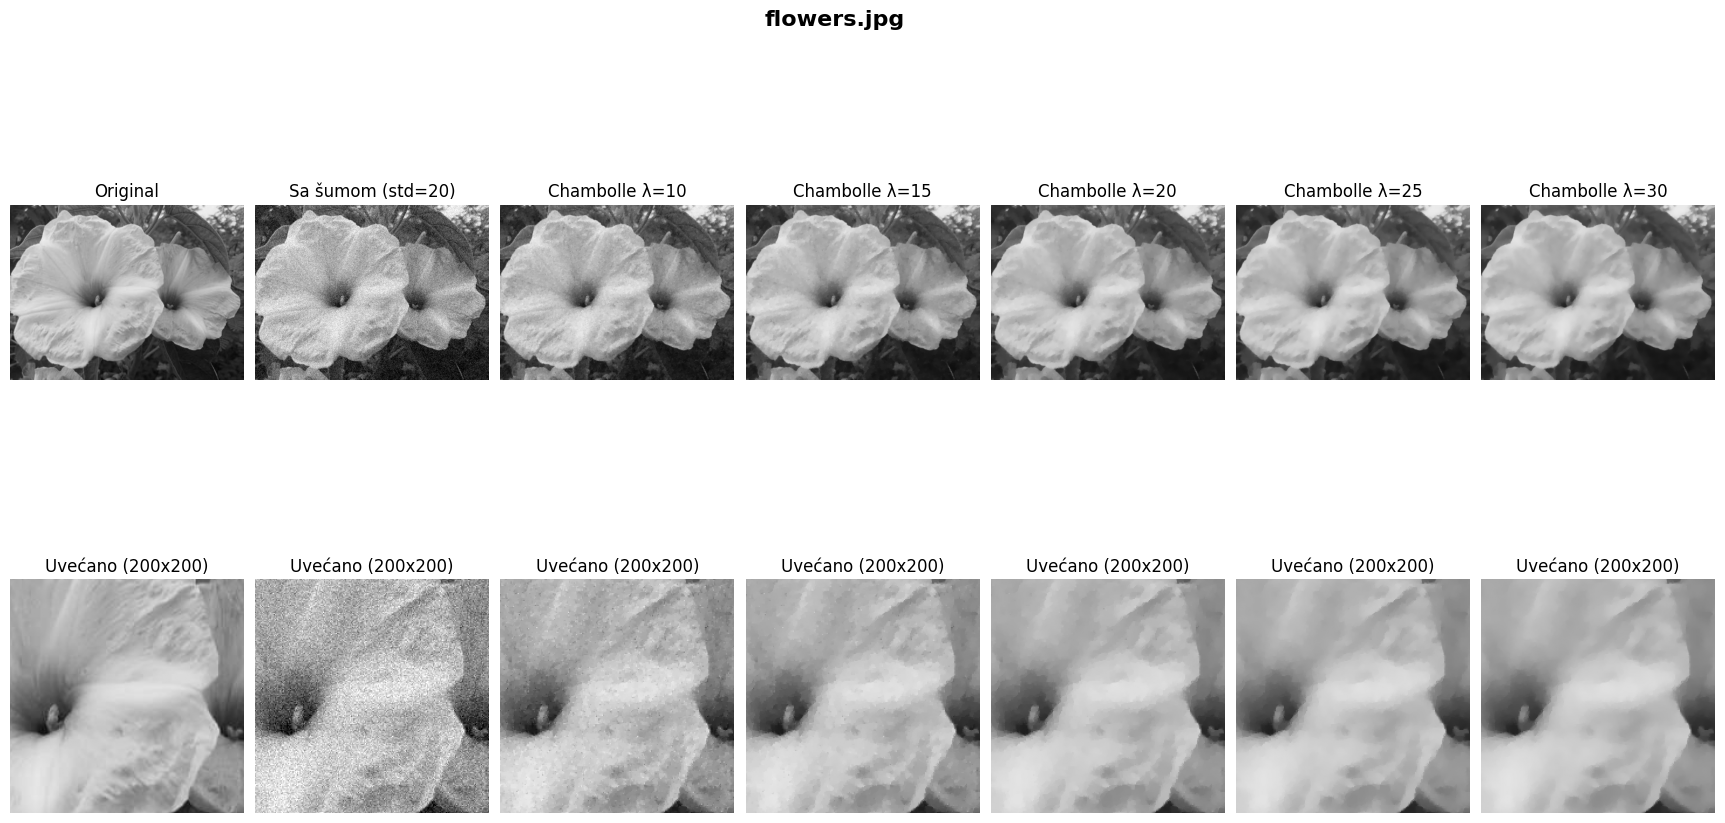

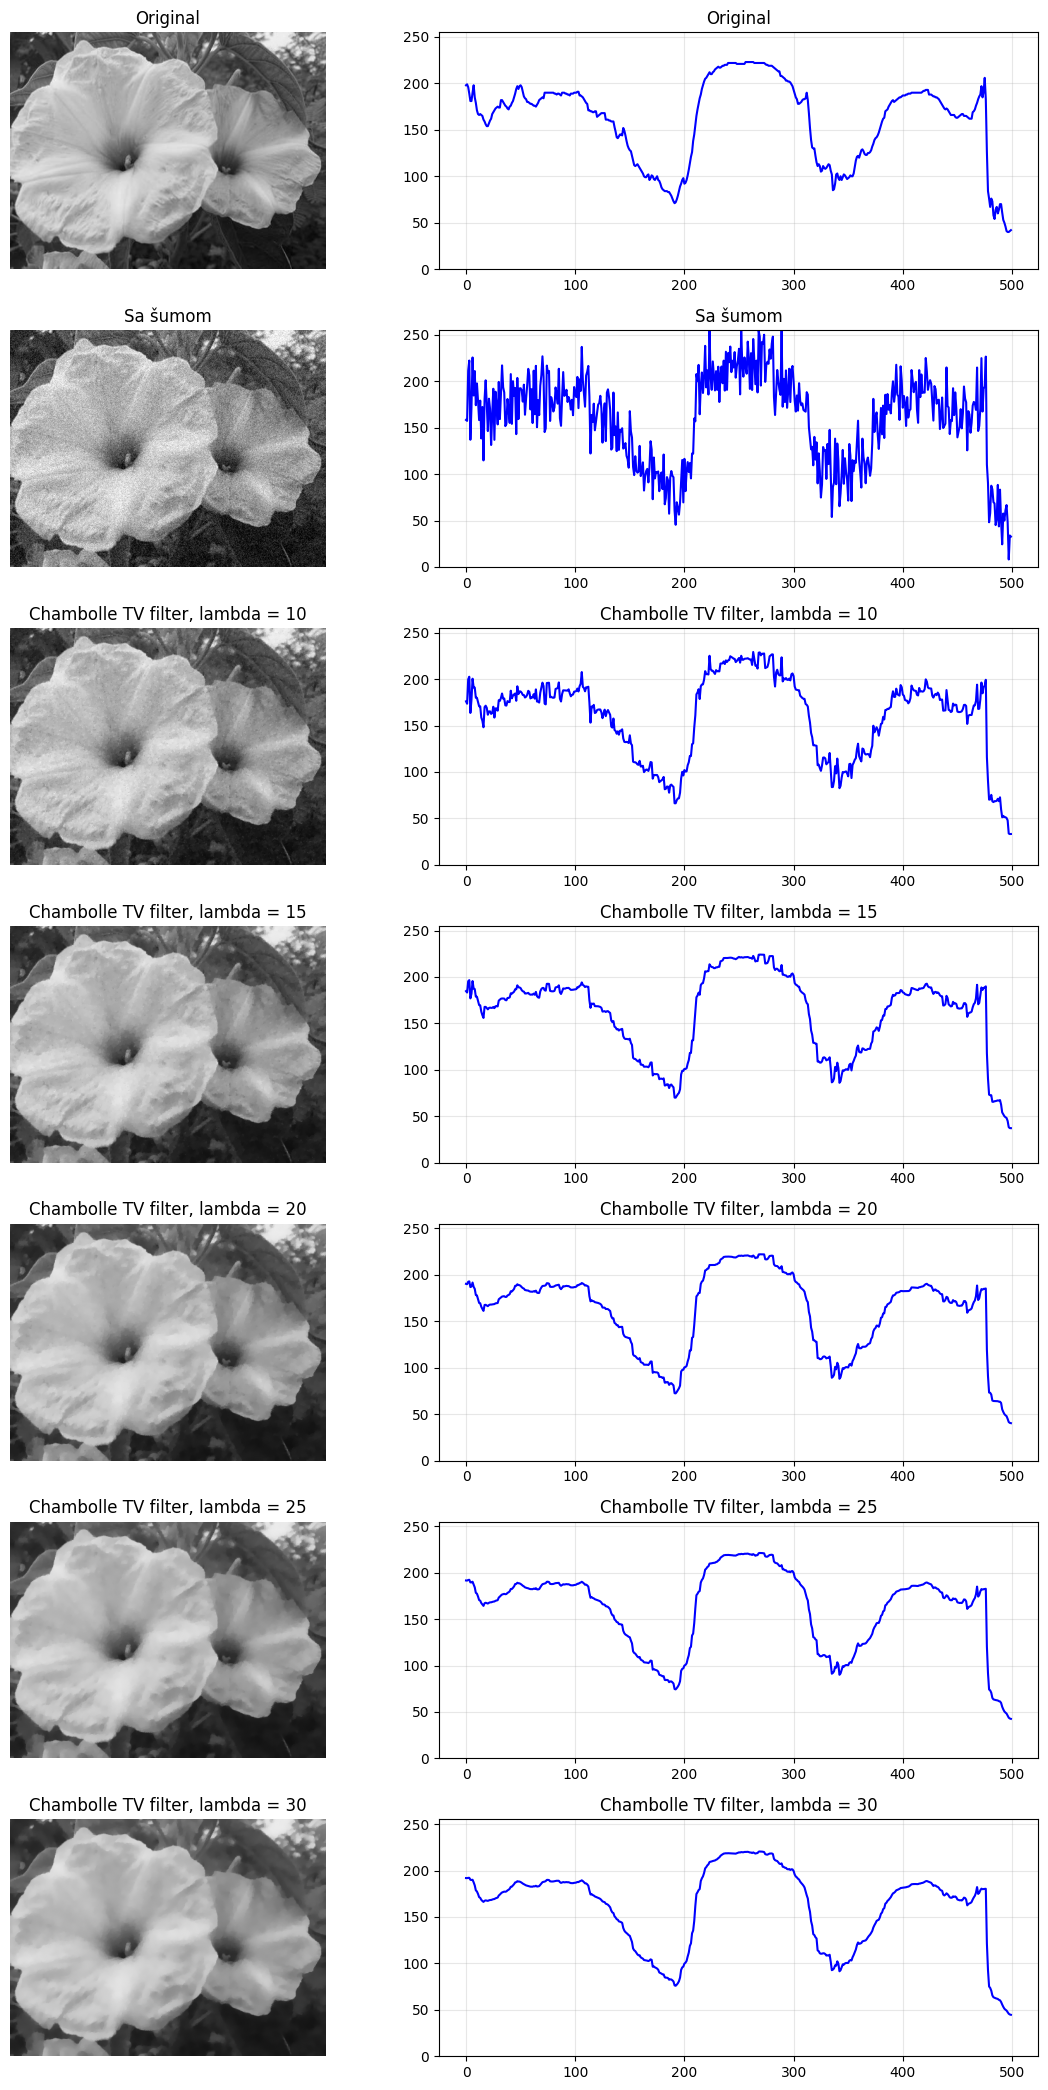


Slika: flowers.jpg

Rezultati za flowers.jpg:


,Noise intensity (std),PSNR Gaussian,PSNR Median,PSNR Chamb TV,SSIM Gaussian,SSIM Median,SSIM Chamb TV,MSE Gaussian,MSE Median,MSE Chamb TV
0,10,31.8 dB,33.61 dB,26.81 dB,0.7821,0.8674,0.7014,42.94,28.34,135.62
1,20,25.99 dB,29.07 dB,31.79 dB,0.5195,0.6873,0.8434,163.59,80.64,43.10
2,30,22.68 dB,26.0 dB,26.27 dB,0.3624,0.5328,0.5529,350.59,163.51,153.54
3,40,20.38 dB,23.63 dB,21.69 dB,0.2662,0.4120,0.3222,596.19,282.11,441.13
4,50,18.69 dB,21.82 dB,18.85 dB,0.2112,0.3348,0.2190,879.34,428.03,847.55


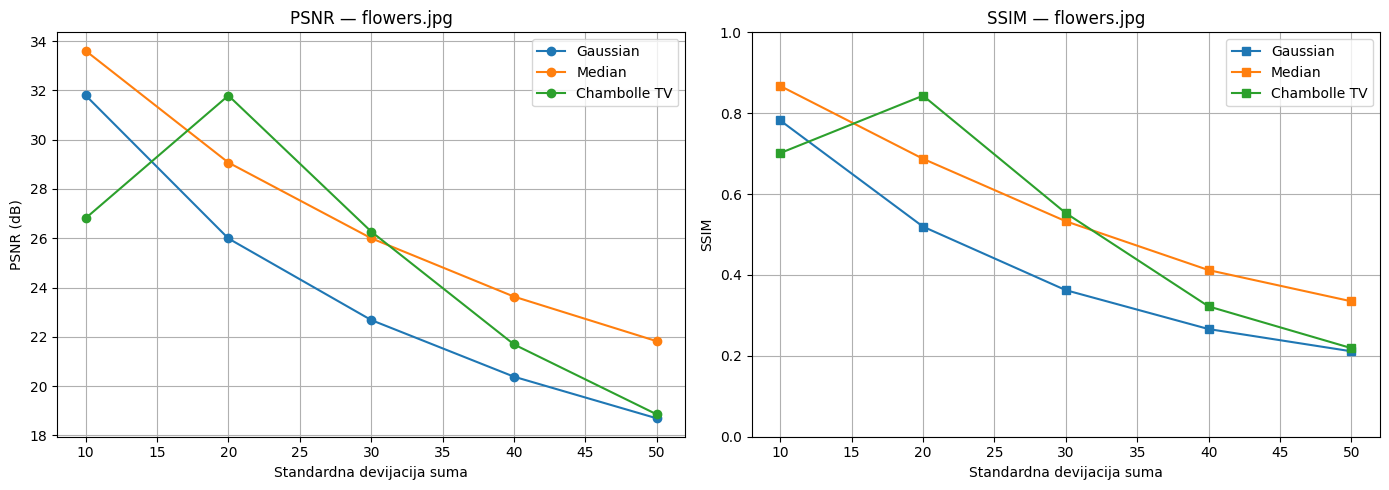

In [13]:
denoise_with_diff_lamda("flowers.jpg")

denoise_different_intensity("flowers.jpg")